In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import verde as vd
from pathlib import Path
import os
from tqdm.auto import tqdm
import geopandas as gpd
from numba import njit, prange
from numba_progress import ProgressBar

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append('./src')

from utilities import *
from block_statistics import *

# BEDMAP1

In [24]:
df1 = gpd.read_file(Path('D:/bedmap/BEDMAP1/shapefiles/BEDMAP1_1966-2000_AIR_BM1_points.shp'))

df1

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,2628,2628,-9999,1,0,-9999,2628,2628,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,332,POINT (121750 1565750)
1,2628,2628,11,2,8,7,2620,2635,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,154,POINT (121250 1565750)
2,2654,2654,12,2,8,8,2646,2663,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,219,POINT (120750 1566250)
3,2684,2684,8,2,6,5,2678,2690,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,155,POINT (120250 1566250)
4,2805,2803,8,3,8,4,2798,2814,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,146,POINT (118250 1567750)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772286,13,13,-9999,1,0,-9999,13,13,1060,1060,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,65,POINT (-558750 359750)
772287,218,218,-9999,1,0,-9999,218,218,1601,1601,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,284,POINT (-554750 463250)
772288,776,776,-9999,1,0,-9999,776,776,1203,1203,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,279,POINT (-547250 441750)
772289,1280,1280,-9999,1,0,-9999,1280,1280,1336,1336,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,288,POINT (-536750 411250)


In [25]:
df1 = df1[df1.Mean_thick != -9999]
df1

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,2628,2628,-9999,1,0,-9999,2628,2628,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,332,POINT (121750 1565750)
1,2628,2628,11,2,8,7,2620,2635,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,154,POINT (121250 1565750)
2,2654,2654,12,2,8,8,2646,2663,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,219,POINT (120750 1566250)
3,2684,2684,8,2,6,5,2678,2690,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,155,POINT (120250 1566250)
4,2805,2803,8,3,8,4,2798,2814,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,146,POINT (118250 1567750)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772286,13,13,-9999,1,0,-9999,13,13,1060,1060,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,65,POINT (-558750 359750)
772287,218,218,-9999,1,0,-9999,218,218,1601,1601,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,284,POINT (-554750 463250)
772288,776,776,-9999,1,0,-9999,776,776,1203,1203,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,279,POINT (-547250 441750)
772289,1280,1280,-9999,1,0,-9999,1280,1280,1336,1336,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,288,POINT (-536750 411250)


In [26]:
coords = df1.geometry.get_coordinates()
df1['x'] = coords['x']
df1['y'] = coords['y']

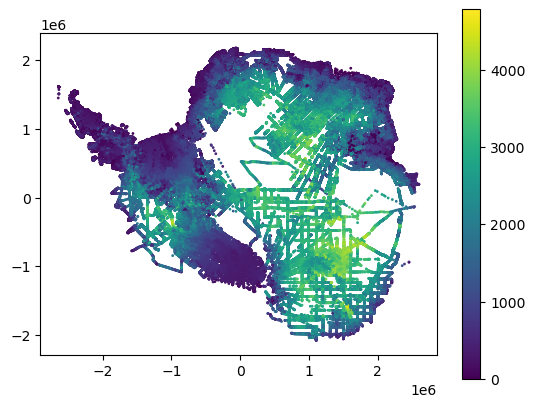

In [27]:
plt.scatter(df1.x, df1.y, c=df1.Mean_thick, s=1)
plt.axis('scaled')
plt.colorbar()
plt.show()

# BEDMAP2

In [36]:
dfs = []

for item in os.scandir(Path('D:/bedmap/BEDMAP2/shapefiles')):
    for item2 in os.scandir(Path(item.path)/'shapePoints'):
        for item3 in os.scandir(Path(item2.path)):
            if item3.name.endswith('.shp'):
                dfs.append(gpd.read_file(item3.path))

df2 = pd.concat(dfs)
df2

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,1493,1493,-9999,1,0,-9999,1493,1493,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,126,POINT (-285250 1557250)
1,1483,1483,-9999,1,0,-9999,1483,1483,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,243,POINT (-284750 1557250)
2,1524,1524,-9999,1,0,-9999,1524,1524,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,157,POINT (-284750 1556750)
3,1581,1581,21,2,15,14,1566,1596,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,202,POINT (-284250 1556750)
4,1594,1594,-9999,1,0,-9999,1594,1594,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,225,POINT (-284250 1556250)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,4105,4103,8,16,11,2,4094,4120,3082,3082,...,-1023,-1019,8,16,11,2,-1038,-1013,151,POINT (1569250 -629750)
75996,4102,4102,5,12,7,1,4093,4110,3082,3082,...,-1020,-1019,5,12,8,1,-1028,-1012,197,POINT (1569250 -629250)
75997,4091,4094,7,16,8,1,4077,4098,3082,3082,...,-1010,-1013,7,16,6,1,-1017,-995,141,POINT (1569250 -628750)
75998,4074,4074,5,15,9,1,4066,4081,3082,3083,...,-991,-992,8,15,9,2,-1011,-981,221,POINT (1569250 -628250)


In [37]:
df2 = df2[df2.Mean_thick != -9999]
df2

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,1493,1493,-9999,1,0,-9999,1493,1493,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,126,POINT (-285250 1557250)
1,1483,1483,-9999,1,0,-9999,1483,1483,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,243,POINT (-284750 1557250)
2,1524,1524,-9999,1,0,-9999,1524,1524,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,157,POINT (-284750 1556750)
3,1581,1581,21,2,15,14,1566,1596,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,202,POINT (-284250 1556750)
4,1594,1594,-9999,1,0,-9999,1594,1594,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,225,POINT (-284250 1556250)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,4105,4103,8,16,11,2,4094,4120,3082,3082,...,-1023,-1019,8,16,11,2,-1038,-1013,151,POINT (1569250 -629750)
75996,4102,4102,5,12,7,1,4093,4110,3082,3082,...,-1020,-1019,5,12,8,1,-1028,-1012,197,POINT (1569250 -629250)
75997,4091,4094,7,16,8,1,4077,4098,3082,3082,...,-1010,-1013,7,16,6,1,-1017,-995,141,POINT (1569250 -628750)
75998,4074,4074,5,15,9,1,4066,4081,3082,3083,...,-991,-992,8,15,9,2,-1011,-981,221,POINT (1569250 -628250)


In [38]:
df2 = df2[df2.Mean_thick != 0]
df2

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,1493,1493,-9999,1,0,-9999,1493,1493,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,126,POINT (-285250 1557250)
1,1483,1483,-9999,1,0,-9999,1483,1483,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,243,POINT (-284750 1557250)
2,1524,1524,-9999,1,0,-9999,1524,1524,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,157,POINT (-284750 1556750)
3,1581,1581,21,2,15,14,1566,1596,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,202,POINT (-284250 1556750)
4,1594,1594,-9999,1,0,-9999,1594,1594,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,225,POINT (-284250 1556250)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,4105,4103,8,16,11,2,4094,4120,3082,3082,...,-1023,-1019,8,16,11,2,-1038,-1013,151,POINT (1569250 -629750)
75996,4102,4102,5,12,7,1,4093,4110,3082,3082,...,-1020,-1019,5,12,8,1,-1028,-1012,197,POINT (1569250 -629250)
75997,4091,4094,7,16,8,1,4077,4098,3082,3082,...,-1010,-1013,7,16,6,1,-1017,-995,141,POINT (1569250 -628750)
75998,4074,4074,5,15,9,1,4066,4081,3082,3083,...,-991,-992,8,15,9,2,-1011,-981,221,POINT (1569250 -628250)


In [39]:
coords = df2.geometry.get_coordinates()
df2['x'] = coords['x']
df2['y'] = coords['y']

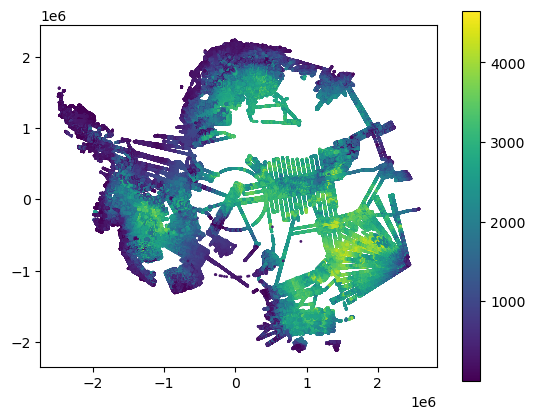

In [40]:
plt.scatter(df2.x, df2.y, c=df2.Mean_thick, s=1)
plt.axis('scaled')
plt.colorbar()
plt.show()

# BEDMAP3

In [41]:
dfs = []

for item in os.scandir(Path('D:/bedmap/BEDMAP3/shapefiles')):
    for item2 in os.scandir(Path(item.path)/'shapePoints'):
        for item3 in os.scandir(Path(item2.path)):
            if item3.name.endswith('.shp'):
                dfs.append(gpd.read_file(item3.path))

df3 = pd.concat(dfs)
df3

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,1450,1447,35,4,40,17,1412,1494,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,248,POINT (847750 1644750)
1,1531,1531,6,2,4,4,1527,1535,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1644250)
2,1567,1567,14,2,10,9,1556,1577,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,181,POINT (847750 1643750)
3,1608,1608,-9999,1,0,-9999,1608,1608,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1643250)
4,1646,1646,-9999,1,0,-9999,1646,1646,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,249,POINT (847750 1642750)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,2890,2890,1,168,0,0,2888,2890,2807,2807,...,-83,-83,1,168,1,0,-84,-81,155,POINT (-7750 -10750)
429,2884,2884,2,168,3,0,2882,2889,2808,2808,...,-77,-76,2,168,3,0,-81,-74,170,POINT (-7750 -9250)
430,2893,2893,2,170,2,0,2889,2895,2808,2808,...,-85,-86,2,170,2,0,-87,-81,237,POINT (-7750 -8750)
431,2897,2897,1,152,2,0,2894,2898,2808,2808,...,-88,-89,1,152,2,0,-90,-86,255,POINT (-7250 -8250)


In [42]:
df3 = df3[df3.Mean_thick != -9999]
df3

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,1450,1447,35,4,40,17,1412,1494,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,248,POINT (847750 1644750)
1,1531,1531,6,2,4,4,1527,1535,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1644250)
2,1567,1567,14,2,10,9,1556,1577,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,181,POINT (847750 1643750)
3,1608,1608,-9999,1,0,-9999,1608,1608,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1643250)
4,1646,1646,-9999,1,0,-9999,1646,1646,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,249,POINT (847750 1642750)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,2890,2890,1,168,0,0,2888,2890,2807,2807,...,-83,-83,1,168,1,0,-84,-81,155,POINT (-7750 -10750)
429,2884,2884,2,168,3,0,2882,2889,2808,2808,...,-77,-76,2,168,3,0,-81,-74,170,POINT (-7750 -9250)
430,2893,2893,2,170,2,0,2889,2895,2808,2808,...,-85,-86,2,170,2,0,-87,-81,237,POINT (-7750 -8750)
431,2897,2897,1,152,2,0,2894,2898,2808,2808,...,-88,-89,1,152,2,0,-90,-86,255,POINT (-7250 -8250)


In [43]:
df3 = df3[df3.Mean_thick != 0]
df3

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,Mean_bed,Med_bed,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry
0,1450,1447,35,4,40,17,1412,1494,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,248,POINT (847750 1644750)
1,1531,1531,6,2,4,4,1527,1535,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1644250)
2,1567,1567,14,2,10,9,1556,1577,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,181,POINT (847750 1643750)
3,1608,1608,-9999,1,0,-9999,1608,1608,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1643250)
4,1646,1646,-9999,1,0,-9999,1646,1646,-9999,-9999,...,-9999,-9999,-9999,0,-9999,-9999,-9999,-9999,249,POINT (847750 1642750)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,2890,2890,1,168,0,0,2888,2890,2807,2807,...,-83,-83,1,168,1,0,-84,-81,155,POINT (-7750 -10750)
429,2884,2884,2,168,3,0,2882,2889,2808,2808,...,-77,-76,2,168,3,0,-81,-74,170,POINT (-7750 -9250)
430,2893,2893,2,170,2,0,2889,2895,2808,2808,...,-85,-86,2,170,2,0,-87,-81,237,POINT (-7750 -8750)
431,2897,2897,1,152,2,0,2894,2898,2808,2808,...,-88,-89,1,152,2,0,-90,-86,255,POINT (-7250 -8250)


In [44]:
coords = df3.geometry.get_coordinates()
df3['x'] = coords['x']
df3['y'] = coords['y']

df3

,Mean_thick,Med_thick,SD_thick,Cnt_thick,IQR_thick,STE_thick,Min_thick,Max_thick,Mean_surf,Med_surf,...,SD_bed,Cnt_bed,IQR_bed,STE_bed,Min_bed,Max_bed,Mean_dist,geometry,x,y
0,1450,1447,35,4,40,17,1412,1494,-9999,-9999,...,-9999,0,-9999,-9999,-9999,-9999,248,POINT (847750 1644750),847750.0,1644750.0
1,1531,1531,6,2,4,4,1527,1535,-9999,-9999,...,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1644250),847750.0,1644250.0
2,1567,1567,14,2,10,9,1556,1577,-9999,-9999,...,-9999,0,-9999,-9999,-9999,-9999,181,POINT (847750 1643750),847750.0,1643750.0
3,1608,1608,-9999,1,0,-9999,1608,1608,-9999,-9999,...,-9999,0,-9999,-9999,-9999,-9999,135,POINT (847750 1643250),847750.0,1643250.0
4,1646,1646,-9999,1,0,-9999,1646,1646,-9999,-9999,...,-9999,0,-9999,-9999,-9999,-9999,249,POINT (847750 1642750),847750.0,1642750.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,2890,2890,1,168,0,0,2888,2890,2807,2807,...,1,168,1,0,-84,-81,155,POINT (-7750 -10750),-7750.0,-10750.0
429,2884,2884,2,168,3,0,2882,2889,2808,2808,...,2,168,3,0,-81,-74,170,POINT (-7750 -9250),-7750.0,-9250.0
430,2893,2893,2,170,2,0,2889,2895,2808,2808,...,2,170,2,0,-87,-81,237,POINT (-7750 -8750),-7750.0,-8750.0
431,2897,2897,1,152,2,0,2894,2898,2808,2808,...,1,152,2,0,-90,-86,255,POINT (-7250 -8250),-7250.0,-8250.0


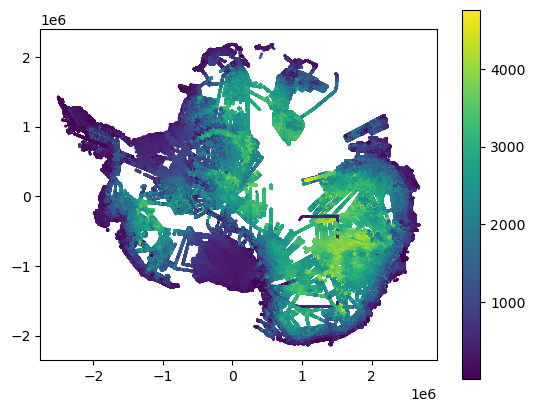

In [45]:
plt.scatter(df3.x, df3.y, c=df3.Mean_thick, s=1)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [47]:
df3.Mean_thick.min()

1